In [ ]:
# http://api.catusita.com:8083/api/sales/forDate?Date1=20250101&Date2=20250115
# http://api.catusita.com:8083/api/stock/forDate?DateStock=20250210
# http://api.catusita.com:8083/api/article/data

In [1]:
import pandas as pd
import numpy as np
import requests
import yfinance as yf
import math
from datetime import datetime, timedelta
from typing import Tuple, Optional


def fetch_data_from_api(url: str, params: dict = None) -> pd.DataFrame:
    try:
        response = requests.get(url, params=params, timeout=10)
        response.raise_for_status()
        data = response.json().get("data", [])
        return pd.DataFrame(data)
    except requests.exceptions.RequestException as e:
        print(f"Error al conectar con la API {url}: {e}")
        return pd.DataFrame()

df_predictions = pd.read_csv("data/cleaned/predictions.csv")
df_rfm = pd.read_csv("data/process/df_rfm.csv")
df_products = pd.read_csv("data/process/catusita_consolidated.csv")
try:
    df_backorder = pd.read_excel("data/raw/catusita/backorder12_12.xlsx")
except FileNotFoundError:
    df_backorder = pd.DataFrame()
prev_day = (datetime.now() - timedelta(days=1)).strftime("%Y%m%d")
df_inventory = fetch_data_from_api("http://api.catusita.com:8083/api/stock/forDate", {"DateStock": prev_day})
df_tc = fetch_data_from_api("http://api.catusita.com:8083/api/article/data")


### to_datime
df_products['fecha'] = pd.to_datetime(df_products['fecha'])
df_predictions['date'] = pd.to_datetime(df_predictions['date'])

df_tc = df_tc[df_tc["lastDateBuy"] != "0001-01-01T00:00:00"]
df_tc["lastDateBuy"] = pd.to_datetime(df_tc["lastDateBuy"], format="%Y-%m-%dT%H:%M:%S", errors="coerce")
df_tc = df_tc[(df_tc["lastDateBuy"] >= "1900-01-01") & (df_tc["lastDateBuy"] <= "2030-12-31")]

### processing data for raw tables
## df_tc
df_tc['codeArticle'] = df_tc['codeArticle'].astype(str)
df_tc['codeArticle'] = df_tc['codeArticle'].str.lower()
df_tc.to_csv('articulos.csv')
df_tc = df_tc.rename(columns={
    'codeArticle':'codigo',
    'lastCurrencyBuy':'moneda',
    'lastPriceBuy':'monto',
    'lastDateBuy':'ultima_fecha',
    'lastQuantityBuy':'ultima_compra'
    })
df_tc = df_tc.dropna(subset=['ultima_fecha'])
df_tc = df_tc[df_tc['ultima_fecha'].notna()]

## df_product
df_products['fecha_mensual'] = df_products['fecha'].dt.to_period('M').dt.to_timestamp()       
# crear variable precio
df_products['precio'] = df_products['venta_pen'] / df_products['cantidad']
# crear variable margen
df_products['margen'] = df_products['venta_pen'] / df_products['costo'] - 1
df_margin_result = df_products.groupby('articulo').agg(
    total_venta_pen=('venta_pen', 'sum'),
    mean_margen=('margen', 'mean')
).reset_index().sort_values(by='total_venta_pen', ascending=False)
# agregar por fecha_mensual, articulo, fuente_suministro 
df_products = df_products.groupby(['fecha_mensual', 'articulo', 'fuente_suministro']).agg({
    # 'descripcion': 'first',
    'cantidad': 'sum',
    'transacciones': 'sum',
    'venta_pen': 'sum', 
    'costo': 'mean',
    'precio': 'mean',
    'lt': 'first'
}).reset_index().rename(columns={'venta_pen': 'total_venta_pen','margen': 'mean_margen'})

## df_predictions
df_predictions = df_predictions.rename(columns={'sku': 'articulo'})

## df_inventory
df_inventory = df_inventory.rename(columns={
    "codeArticle": "codigo",
    "umArticle": "um",
    "stock": "stock"
})
df_inventory.loc[:, 'codigo'] = df_inventory['codigo'].str.lower()
df_inventory = df_inventory.groupby(['codigo','um']).agg(
    {
        'stock':'sum'
    }
).reset_index()



# Get currency data 
start = df_tc['ultima_fecha'].min().date()
end = df_tc['ultima_fecha'].max().date()
currency_pairs = ['PENUSD=X', 'EURUSD=X', 'JPYUSD=X', 'GBPUSD=X']
data = yf.download(currency_pairs, start=start, end=end)
df_closing_prices = data['Close']
df_closing_prices.columns = [col.split('.')[0] for col in df_closing_prices.columns]

# process currency data
df_long_format = df_closing_prices.reset_index().melt(id_vars='Date', var_name='Currency Pair', value_name='Closing Price')
df_long_format['Currency Pair'] = df_long_format['Currency Pair'].str.replace('=X', '', regex=False)
df_long_format = df_long_format.dropna(subset=['Closing Price'])

full_date_range = pd.date_range(start=df_long_format['Date'].min(), end=df_long_format['Date'].max(), freq='D')
currency_pairs = df_long_format['Currency Pair'].unique()
complete_index = pd.MultiIndex.from_product([full_date_range, currency_pairs], names=['Date', 'Currency Pair'])
df_temp = pd.DataFrame(index=complete_index).reset_index()

df_long_format = df_temp.merge(df_long_format, on=['Date', 'Currency Pair'], how='left')
df_long_format['Closing Price'] = df_long_format.groupby('Currency Pair')['Closing Price'].ffill()
df_long_format = df_long_format.rename(columns={'Closing Price': 'tc'})

# merge exchange rates
df_tc_merged = pd.merge(df_tc, df_long_format, left_on='ultima_fecha', right_on='Date', how='left')
df_tc_merged['monto'] = pd.to_numeric(df_tc_merged['monto'], errors='coerce')
df_tc_merged['tc'] = pd.to_numeric(df_tc_merged['tc'], errors='coerce')

def convert_to_usd(row):
    if pd.isna(row['Currency Pair']) or row['moneda'] == 'USD':
        return row['monto']
    currency_pair_map = {'SOL': 'PENUSD', 'EUR': 'EURUSD', 'JPY': 'JPYUSD', 'GBP': 'GBPUSD'}
    if row['moneda'] in currency_pair_map and row['Currency Pair'] == currency_pair_map[row['moneda']]:
        return row['monto'] / row['tc'] if row['moneda'] == 'SOL' else row['monto'] * row['tc']
    return 0

df_tc_merged['monto_usd'] = df_tc_merged.apply(convert_to_usd, axis=1)
df_tc_merged = df_tc_merged[df_tc_merged['monto_usd'] != 0]
df_tc_final = df_tc_merged[['codigo', 'ultima_fecha', 'monto_usd', 'ultima_compra']]
df_tc_final = df_tc_final[df_tc_final['monto_usd'].notna()]

# cleaning df_inventory with df_products
# max_date = df_inventory['date'].max()
# df_inventory = df_inventory[
#     (df_inventory['date'] != 'Periodo') & 
#     (df_inventory['date'].notna())&
#     (df_inventory['date']==max_date)
# ]
df_inventory_final=pd.concat(
    [
        pd.DataFrame(df_inventory['codigo'].unique(), columns=['codigo']),
        pd.DataFrame(df_products['articulo'].unique(), columns=['codigo'])
    ], 
    ignore_index=True
).drop_duplicates()
df_inventory = df_inventory_final.merge(
#    df_inventory[['date','codigo','stock']].drop_duplicates(),
    df_inventory[['codigo','stock']].drop_duplicates(),
    how='left',
    on='codigo'
)
df_inventory['stock']=df_inventory['stock'].fillna(0)
# df_inventory['date'] = df_inventory['date'].fillna(max_date)
# merging df_predictions, df_products and df_invetory
df_merged = df_predictions.copy()
df_merged = df_merged.merge(
    df_products[['articulo','fuente_suministro']].drop_duplicates(), 
    how='left', 
    on = 'articulo'
)
df_merged = df_merged.merge(
    df_inventory[['codigo','stock']], 
    how='left', 
    left_on=['articulo'],
    right_on=['codigo']
)

# merging df_tc_final, df_backorder, rfm and df_margin_result
df_merged = df_merged.merge(
    df_margin_result[['articulo', 'mean_margen']], 
    how='left', 
    on='articulo'
)
df_merged = df_merged.merge(
    df_tc_final, 
    how='left', 
    left_on='articulo', 
    right_on='codigo'
)
if not df_backorder.empty:
    df_merged = df_merged.merge(
        df_backorder, 
        how='left', 
        on='articulo'
    )
else:
    df_merged['backorder'] = np.nan
df_merged = df_merged.merge(
    df_rfm, 
    left_on='articulo',
    right_on='sku',
    how='left'
)
df_merged['rfm'] = df_merged['rfm'].fillna(0).astype(int)
df_merged = df_merged.drop_duplicates()

# adding demanda_mensual and meses_proteccion    
df_merged['demanda_mensual'] = df_merged['caa'] / df_merged['lt']
df_merged['meses_proteccion'] = df_merged['corr_sd'] / df_merged['demanda_mensual']

# modificar period2 (caa_lt)
df_merged['caa_lt'] += df_merged['corr_sd'] * df_merged['rfm'].map({3: 0.4, 2: 0.3, 1: 0.2, 0: 0.1}).fillna(0)

# adding compra_sugerida
df_merged['sobrante'] = np.maximum(df_merged['stock'].fillna(0) + df_merged['backorder'].fillna(0) - df_merged['caa'], 0)
df_merged['compra_sugerida'] = np.maximum(df_merged['caa_lt'].fillna(0) - df_merged['sobrante'], 0)
df_merged['compra_sugerida'] = np.ceil(df_merged['compra_sugerida']).astype('Int64')
df_merged['compra_sugerida'] = df_merged['compra_sugerida'].astype("Float64")
df_merged['meses_proteccion'] = df_merged['meses_proteccion'].astype("Float64")
# mask = df_merged['demanda_mensual'] != 0
# df_merged.loc[mask, 'meses_proteccion'] = (
#     df_merged.loc[mask, 'meses_proteccion'] * 
#     (df_merged.loc[mask, 'compra_sugerida'].fillna(0) / df_merged.loc[mask, 'demanda_mensual'])
# ).astype("Float64")

# adding costo_compra and compras_recomendadas
# df_merged = df_merged.rename(columns={'caa': 'compras_recomendadas'})
df_merged = df_merged.rename(columns={'compra_sugerida': 'compras_recomendadas'})
df_merged.loc[df_merged['demanda_mensual'] < 0, 'demanda_mensual'] = 0
df_merged.loc[df_merged['compras_recomendadas'] < 0, 'compras_recomendadas'] = 0
df_merged['compras_recomendadas'] = df_merged['compras_recomendadas'].apply(
    lambda x: math.ceil(x / 50) * 50 if pd.notna(x) else pd.NA
)
df_merged['costo_compra'] = df_merged['monto_usd'] * df_merged['compras_recomendadas']

# Calcular riesgo
df_merged['holgura'] = (df_merged['stock'] / df_merged['demanda_mensual']).fillna(0)
df_merged['consumiendo_proteccion'] = (df_merged['holgura'] < df_merged['meses_proteccion']).astype('Int64')
df_merged['quebro'] = (df_merged['holgura'] <= 0).astype('Int64')
df_merged['va_a_quebrar'] = ((df_merged['stock'] + df_merged['backorder']) < df_merged['demanda_mensual']).astype('Int64')
df_merged['verde'] = (
    (df_merged['quebro'] == 0) & 
    (df_merged['consumiendo_proteccion'] == 0) & 
    (df_merged['va_a_quebrar'] == 0)
).astype('Int64')
df_merged['amarillo'] = (
    (df_merged['consumiendo_proteccion'] == 1) & 
    (df_merged['quebro'] == 0)
).astype('Int64')
df_merged['rojo'] = (
    (df_merged['quebro'] == 1) |
    (df_merged['va_a_quebrar'] == 1) 
).astype('Int64')
df_merged['riesgo'] = df_merged.apply(
    lambda row: 'rojo' if pd.notna(row.get('rojo')) and row['rojo'] == 1 else 
                'amarillo' if pd.notna(row.get('amarillo')) and row['amarillo'] == 1 else 
                ('verde' if pd.notna(row.get('rojo')) or pd.notna(row.get('amarillo')) else np.nan),
    axis=1
)

# filtrar solo las importantes para la tabla por fuente de suministro
df_merged['demanda_mensual_usd'] = df_merged['demanda_mensual'] * df_merged['monto_usd']
df_temp = df_merged.copy()
df_temp = df_temp[(df_temp['rfm'] == 3) & (df_temp['riesgo'] == 'rojo')]
df_temp = df_temp.groupby('fuente_suministro').agg(
    recomendacion=('costo_compra', 'sum'),
    demanda_mensual_usd=('demanda_mensual_usd', 'sum')
).reset_index()
df_temp_2 = df_merged.groupby('fuente_suministro').agg(
    lead_time=('lt', 'first'),
    riesgo=('riesgo', lambda x: x.mode()[0] if not x.mode().empty else None)
).reset_index()
df_dashboard_by_fuente = df_temp_2.merge(df_temp, how='left', on='fuente_suministro')
df_dashboard_by_fuente['recomendacion'] = pd.to_numeric(df_dashboard_by_fuente['recomendacion'], errors='coerce').fillna(0).astype(int)
df_dashboard_by_fuente['demanda_mensual_usd'] = pd.to_numeric(df_dashboard_by_fuente['demanda_mensual_usd'], errors='coerce').fillna(0).astype(int)

# dar formato
df_dashboard_by_fuente['riesgo_color'] = df_dashboard_by_fuente['riesgo'].map({
    'verde': '🟢',
    'amarillo': '🟡',
    #'naranja': '🟠',
    'rojo': '🔴'
})
df_download = df_merged[[
    'date','articulo','fuente_suministro','stock','compras_recomendadas','demanda_mensual',
    'meses_proteccion','riesgo','lt','mean_margen','ultima_fecha','monto_usd',
    'ultima_compra','costo_compra','rfm','backorder','holgura','quebro','va_a_quebrar','consumiendo_proteccion'
]]
df_dashboard = df_merged[[
    'date','articulo','fuente_suministro','stock','backorder','rfm','riesgo',
    'demanda_mensual','monto_usd','ultima_compra','compras_recomendadas','costo_compra'
]]
df_dashboard_by_fuente = df_dashboard_by_fuente[[
    'fuente_suministro',
    'lead_time',
    'recomendacion',
    'demanda_mensual_usd'
]]
# columns mapping
display_columns = {
    'date': 'Fecha',
    'articulo': 'Artículo',
    'fuente_suministro': 'Fuente Suministro',
    'stock': 'Inventario',
    'backorder': 'Backorder',
    'compras_recomendadas': 'Compras Recomendadas',
    'rfm':'Importancia RFM',
    'riesgo': 'Alerta',
    'monto_usd': 'Monto USD',
    'ultima_compra': 'Última Compra',
    'demanda_mensual': 'Demanda Mensual',
    'lt': 'Lead Time',
    'mean_margen': 'Margen',
    'meses_proteccion': 'Meses proteccion',
    'ultima_fecha': 'Ultima fecha',
    'costo_compra': 'Recomendacion USD'
    }
display_columns_fuente = {
    'date': 'Fecha',
    'fuente_suministro': 'Fuente de Suministro',
    'lead_time': 'Lead Time',
    'recomendacion': 'Recomendacion USD',
    'demanda_mensual_usd': 'Demanda Mensual USD'
}
df_dashboard = df_dashboard.rename(columns=display_columns)
df_download = df_download.rename(columns=display_columns)
df_dashboard_by_fuente = df_dashboard_by_fuente.rename(columns=display_columns_fuente)


YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  4 of 4 completed


In [8]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression, Lasso
import xgboost as xgb
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

class Predictor:
    def __init__(self):
        self.scaler = StandardScaler()

    def load_and_preprocess_data(self, data_path):
        df = pd.read_csv(data_path)
        df['fecha'] = pd.to_datetime(df['fecha'])
        df = df.sort_values(by=['articulo', 'fecha'])
        return df

    def load_covariates_data(self, cov_path):
        return pd.read_csv(cov_path)

    def create_monthly_sales_data(self, df):
        df.loc[:, 'year'] = df['fecha'].dt.year
        df.loc[:, 'month'] = df['fecha'].dt.month

        monthly_data = df.groupby(['articulo', 'year', 'month']).agg({
            'cantidad': 'sum',
            'transacciones': 'sum',
            'venta_pen': 'sum',
            'fuente_suministro': 'first',
            'lt': 'first'
        }).reset_index()

        monthly_data['fecha'] = pd.to_datetime(monthly_data.apply(
            lambda row: pd.Timestamp(year=int(row['year']), month=int(row['month']), day=1), axis=1))
        monthly_data['lt'] = monthly_data['lt'].fillna(0)

        hoy = pd.Timestamp.today()
        primer_dia_mes_actual = pd.Timestamp(hoy.year, hoy.month, 1)
        fecha_limite = primer_dia_mes_actual - pd.DateOffset(months=1)

        monthly_data = monthly_data[monthly_data['fecha'] <= fecha_limite]

        return monthly_data.sort_values(by=['articulo', 'fecha'])

    def select_features_with_lasso(self, X, y, feature_columns, alpha=0.01):
        """
        Perform feature selection using LASSO regression.
        Returns selected feature names based on non-zero coefficients.
        """
        X_scaled = self.scaler.fit_transform(X)
        
        lasso = Lasso(alpha=alpha, random_state=42)
        lasso.fit(X_scaled, y)
        
        selected_features = [feature for feature, coef in zip(feature_columns, lasso.coef_) 
                        if abs(coef) > 0]
                
        return selected_features

    def prepare_features_for_ml(self, all_monthly_data, df_cov, df_correlaciones_sig, sku):
        sku_correlations = df_correlaciones_sig[df_correlaciones_sig['sku'] == sku]
        
        if len(sku_correlations) == 0:
            return all_monthly_data[all_monthly_data['articulo'] == sku].copy(), []
            
        data = all_monthly_data[all_monthly_data['articulo'] == sku].merge(
            df_cov, on=['year', 'month'], how='left'
        )
        
        feature_columns = []
        for _, row in sku_correlations.iterrows():
            col_name = row['tipo']
            lag = row['lag']
            if lag > 0:
                data[f'{col_name}_lag_{lag}'] = data[col_name].shift(lag)
                feature_columns.append(f'{col_name}_lag_{lag}')
            else:
                feature_columns.append(col_name)
        
        data = data.dropna(axis=1, how='all')
        data = data.fillna(0)
        start_col = data.columns.get_loc("fecha")
        feature_columns = data.iloc[:, start_col + 1:].columns
        feature_columns = feature_columns.tolist()
        
        if len(data) > 0 and len(feature_columns) > 0:
            X = data[feature_columns]
            y = data['cantidad']
            selected_features = self.select_features_with_lasso(X, y, feature_columns)
            return data, selected_features
        
        return data, []

    def weighted_mape(self, y_true, y_pred):
        errors = []
        for true, pred in zip(y_true, y_pred):
            if pd.isna(true) or pd.isna(pred) or true == 0:
                continue
            error = abs((true - pred) / true)
            if pred < true: 
                error *= 2
            errors.append(error)
        return np.mean(errors) * 100 if errors else float('inf')

    def ES_forecast(self, series, alpha):
        series = np.array(series)
        result = [series[0]]
        for n in range(1, len(series)):
            result.append(alpha * series[n] + (1 - alpha) * result[n-1])
        return result[-1]

    def ES_opt_alpha(self, series):
        series = np.array(series)
        alpha_list = np.linspace(0.1, 0.9, 100)
        errors = []
        
        for alpha in alpha_list:
            error = []
            for i in range(1, len(series)-1):
                forecast = self.ES_forecast(series[:i], alpha)
                error.append(abs(forecast - series[i+1]))
            errors.append(np.mean(error))
        
        return alpha_list[np.argmin(errors)]

    def evaluate_models(self, data, feature_columns, target_col='cantidad', 
                    lookback_periods=[6, 12, None], val_year=None):
        best_score = float('inf')
        best_config = None
        best_model = None
        
        data = data.sort_values(by='fecha')

        if len(data) < 4:
            return None, None, float('inf')
            
        # val_data = data[data['year'] == val_year] if val_6year else data
        val_data = data
        val_size = 6
        
        for lookback in lookback_periods:
            train_data = (val_data.iloc[-(lookback+val_size):-val_size] 
                        if lookback else val_data.iloc[:-val_size])
            test_data = val_data.iloc[-val_size:]
                
            y_train = train_data['cantidad']
            y_test = test_data['cantidad']
            
            models = {
                'mean': y_train.mean(),
                'median': y_train.median(),
                'es': (self.ES_forecast, self.ES_opt_alpha(y_train))
            }
            
            if len(feature_columns) > 0:
                models.update({
                    'xgboost': xgb.XGBRegressor(random_state=42),
                    'linear': LinearRegression()
                })
                X_train = train_data[feature_columns]
                X_test = test_data[feature_columns]
            
            for model_name, model in models.items():
                try:
                    if model_name in ['xgboost', 'linear']:
                        model.fit(X_train, y_train)
                        y_pred = model.predict(X_test)
                    elif model_name == 'es':
                        forecast_func, alpha = model
                        y_pred = []
                        current_data = y_train.values
                        for _ in range(len(y_test)):
                            pred = forecast_func(current_data, alpha)
                            y_pred.append(pred)
                            current_data = np.append(current_data, pred)
                    else:  # mean or median
                        y_pred = [model] * len(y_test)
                    
                    y_pred = np.maximum(y_pred, 0)
                    score = self.weighted_mape(y_test, y_pred)
                
                    # print(f"Modelo: {model_name}, Lookback: {lookback}, Score: {score}, y_pred: {y_pred}")

                    if score < best_score:
                        best_score = score
                        best_config = (model_name, lookback)
                        best_model = model
                        
                except Exception as e:
                    continue
        
        return best_config, best_model, best_score

    def predict_future_months(self, data, feature_columns, best_model, 
                            best_model_name, lookback, num_months):
        predictions = []
        current_data = data.copy()
        current_data = current_data.sort_values(by="fecha")

        fecha_actual = current_data['fecha'].max()
        primer_dia_mes_actual = pd.Timestamp(fecha_actual.year, fecha_actual.month, 1)
        fecha_inicio = primer_dia_mes_actual - pd.DateOffset(months=5)
        ultimos_seis_meses = current_data[
            (current_data['fecha'] >= fecha_inicio) & (current_data['fecha'] <= primer_dia_mes_actual)
        ]

        for _ in range(num_months):
            if best_model_name in ['xgboost', 'linear']:
                pred = best_model.predict(current_data[feature_columns].iloc[-1:])[0]
            elif best_model_name in ['mean', 'median']:
                if not ultimos_seis_meses.empty:
                    pred = (ultimos_seis_meses['cantidad'].sum())/6 if best_model_name == 'mean' else ultimos_seis_meses['cantidad'].median()
                else:
                    pred = 0 
            else:  # ES
                forecast_func, alpha = best_model
                lookback_data = (current_data.iloc[-lookback:] if lookback 
                                else current_data)
                pred = forecast_func(lookback_data['cantidad'], alpha)
            
            pred = np.maximum(pred, 0)
            predictions.append(pred)
            
            new_row = current_data.iloc[-1:].copy()
            new_row['cantidad'] = pred
            new_row['fecha'] += pd.DateOffset(months=1)
            new_row['month'] = new_row['fecha'].dt.month
            new_row['year'] = new_row['fecha'].dt.year
            
            current_data = pd.concat([current_data, new_row])
            
            if feature_columns:
                for lag in range(1, 4):
                    current_data[f'cantidad_lag_{lag}'] = current_data['cantidad'].shift(lag)
        
        return predictions

    def make_final_predictions(self, all_monthly_data, df_cov, df_correlaciones_sig, articulo):
        results = []
        no_sku_process_list = []
        count = 0
        # for sku in all_monthly_data['articulo'].unique():
        # "wk-1060/1","ghm10028a"
        for sku in [articulo]:
            print(f"Processing SKU: {sku}")
            try:
                sku_data = all_monthly_data[all_monthly_data['articulo'] == sku].copy()
                last_date = sku_data['fecha'].max()
                last_date = (last_date + pd.offsets.MonthBegin(1)).normalize()
                lt = int(sku_data['lt'].iloc[-1])
                last_year = sku_data['year'].max()

                data, feature_columns = self.prepare_features_for_ml(
                    all_monthly_data, df_cov, df_correlaciones_sig, sku
                )

                best_config, best_model, score = self.evaluate_models(
                    data,
                    feature_columns,
                    lookback_periods=[6, 12, None],
                    val_year=last_year - 1
                )
                
                hoy = pd.Timestamp.today()
                primer_dia_mes_actual = pd.Timestamp(hoy.year, hoy.month, 1)
                fecha_inicio = primer_dia_mes_actual - pd.DateOffset(months=5)
                ultimos_seis_meses = sku_data[
                    (sku_data['fecha'] >= fecha_inicio) & (sku_data['fecha'] <= primer_dia_mes_actual)
                ]
                catusita = (ultimos_seis_meses['cantidad'].sum())/6

                if best_config is None or best_model is None:
                    sku_data = sku_data.sort_values(by='fecha')
                    
                    if not ultimos_seis_meses.empty:
                        avg_cantidad = (ultimos_seis_meses['cantidad'].sum())/6
                        caa = avg_cantidad * lt
                        caa_lt = avg_cantidad * lt
                        catusita = avg_cantidad * lt
                        best_model_name = 'mean'
                    else:
                        caa = np.nan
                        caa_lt = np.nan
                        best_model_name = np.nan

                    results.append({
                        'sku': sku,
                        'lt': lt,
                        'date': last_date,
                        'model': best_model_name,
                        'real': 0,
                        'catusita': catusita,
                        'lookback_period': np.nan,
                        'features_used': 'none',
                        'caa': caa,
                        'caa_lt': caa_lt,
                        'corr_sd': np.nan,
                        'loss': np.nan
                    })

                    no_sku_process_list.append({'sku': sku})
                    count += 1
                    continue

                best_model_name, lookback = best_config

                # Generate future predictions
                future_predictions = self.predict_future_months(
                    data,
                    feature_columns,
                    best_model,
                    best_model_name,
                    lookback,
                    2 * lt
                )

                # Calculate pred_std from the historical data used for prediction
                if lookback:
                    historical_data = data['cantidad'].iloc[-lookback:]
                else:
                    historical_data = data['cantidad']
                pred_std = np.std(historical_data)

                period1 = sum(future_predictions[:lt])
                period2 = sum(future_predictions[lt:2*lt])
                
                last_six_months_mean = ((ultimos_seis_meses['cantidad'].sum())/6) * lt

                # Reemplazar predicción si es 0 y hay al menos un valor en ese rango
                if (
                    period1 == 0 and period2 == 0 and
                    ultimos_seis_meses['cantidad'].notna().sum() > 0
                ):
                    avg_cantidad = (ultimos_seis_meses['cantidad'].sum())/6
                    period1 = avg_cantidad * lt
                    period2 = avg_cantidad * lt
                    best_model_name = 'mean'

                # Registro final
                results.append({
                    'sku': sku,
                    'lt': lt,
                    'date': last_date,
                    'model': best_model_name,
                    'real': 0,
                    'catusita': last_six_months_mean,
                    'lookback_period': lookback if lookback else 'all',
                    'features_used': ','.join(feature_columns) if feature_columns else 'none',
                    'caa': period1,
                    'caa_lt': period2,
                    'corr_sd': pred_std,
                    'loss': score
                })

            except Exception as e:
                print(f"Error processing SKU {sku}: {str(e)}")
                continue
        print(f"El numero de SKU sin procesar: {count}")
        # return pd.DataFrame(future_predictions)
        return future_predictions

    def process_predictions(self, articulo):
        from utils.process_data.config import DATA_PATHS
        
        data_path = DATA_PATHS['process'] / 'catusita_consolidated.csv'
        cov_path = DATA_PATHS['process'] / 'df_covariables.csv'
        
        all_monthly_data = self.create_monthly_sales_data(
            self.load_and_preprocess_data(data_path)
        )
        df_cov = self.load_covariates_data(cov_path)
        df_correlaciones_sig = pd.read_csv(DATA_PATHS['process'] / 'df_correlaciones_sig.csv')
        
        results_df = self.make_final_predictions(
            all_monthly_data, 
            df_cov, 
            df_correlaciones_sig,
            articulo
        )

        # results_df = results_df[results_df['date'] == results_df['date'].max()]
        return results_df


Processing SKU: 99939
El numero de SKU sin procesar: 0
    articulo fuente_suministro   lt          caa
552    99939   versachem - usa  1.0  6730.066796


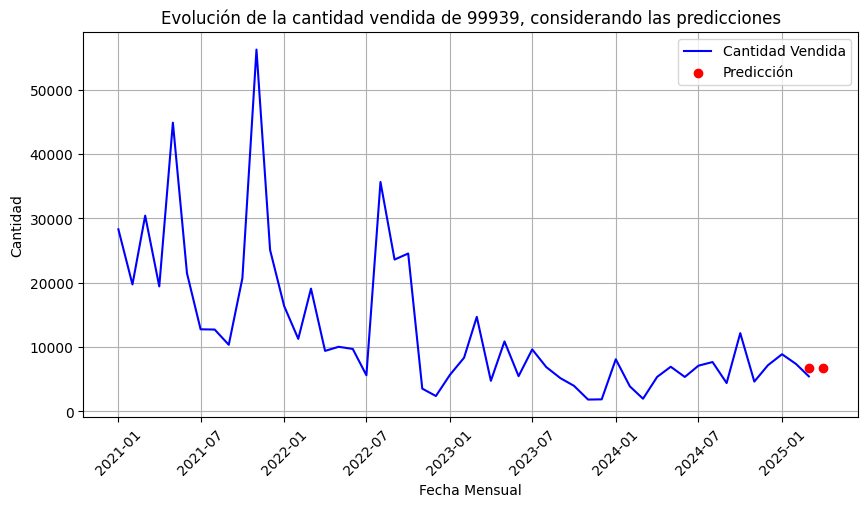

In [9]:
import matplotlib.pyplot as plt
import pandas as pd

articulo_mas_venta = df_margin_result.iloc[2]['articulo']
pred = Predictor()
predictions = pred.process_predictions(articulo_mas_venta)
df_ppt = df_products.merge(df_inventory[['codigo','stock']], how='left',left_on='articulo',right_on='codigo')
df_ppt = df_ppt.merge(df_predictions[['articulo','model','caa','caa_lt']], how='left',on='articulo')
df_ppt = df_ppt[df_ppt['articulo']==articulo_mas_venta]
print(df_ppt[df_ppt['articulo']==articulo_mas_venta][['articulo','fuente_suministro','lt','caa',]].head(1))

df_ppt2 = df_products[df_products['articulo'] == articulo_mas_venta][['fecha_mensual', 'articulo', 'cantidad']]
df_ppt3_original = df_merged[df_merged['articulo'] == articulo_mas_venta][['lt','caa', 'caa_lt']]
lt = df_ppt3_original['lt'].unique()[0]
primer_mes = "2025-03-01"
fechas_mensuales = pd.date_range(start=primer_mes, periods=lt*2, freq='MS')
df_ppt3 = pd.DataFrame({
    "fecha_mensual": fechas_mensuales,
    "cantidad": predictions
})
plt.figure(figsize=(10,5))
plt.plot(df_ppt2["fecha_mensual"], df_ppt2["cantidad"], linestyle="-", color="b", label="Cantidad Vendida")

# Agregar los puntos de predicción con las fechas correctas
plt.scatter(df_ppt3["fecha_mensual"], df_ppt3["cantidad"], color="r", marker="o", label="Predicción")

# Etiquetas y título
plt.xlabel("Fecha Mensual")
plt.ylabel("Cantidad")
plt.title(f"Evolución de la cantidad vendida de {articulo_mas_venta}, considerando las predicciones")
plt.legend()
plt.grid(True)

# Mostrar el gráfico
plt.xticks(rotation=45)
plt.show()
